# ABB Capstone — Data Prep & Exploration

## Setup (imports + file paths)

In [37]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.dates as mdates
from pathlib import Path

base = Path("data")

files = {
    "dsw_order_intake": base/"DSW Order Intake Data 2023-2025.xlsx",
    "retro_order_intake": base/"Retrofit Order Intake data 2023-2025.xlsx",
    "retro_country": base/"Retrofit orders by Country.xlsx",
    "dsw_overtime": base/"DSW_overtime hours_2025.xlsx",
    "retro_overtime": base/"Retro_overtime hours_2025.xlsx",
    "modernization_ts": base/"Modernization confirmation time stamp lead time data.xlsx",
    "dsw_lead": base/"DSW FI Lead Time.xlsx",
    "abb_data": base/"ABB Data.xlsx",
}
{k:str(v) for k,v in files.items()}

{'dsw_order_intake': 'data/DSW Order Intake Data 2023-2025.xlsx',
 'retro_order_intake': 'data/Retrofit Order Intake data 2023-2025.xlsx',
 'retro_country': 'data/Retrofit orders by Country.xlsx',
 'dsw_overtime': 'data/DSW_overtime hours_2025.xlsx',
 'retro_overtime': 'data/Retro_overtime hours_2025.xlsx',
 'modernization_ts': 'data/Modernization confirmation time stamp lead time data.xlsx',
 'dsw_lead': 'data/DSW FI Lead Time.xlsx',
 'abb_data': 'data/ABB Data.xlsx'}

## Load datasets

In [4]:
def read_first_sheet(path):
    xl = pd.ExcelFile(path)
    return xl.sheet_names, pd.read_excel(path, sheet_name=xl.sheet_names[0])

sheets = {}
dfs = {}
for k,p in files.items():
    try:
        sh, df = read_first_sheet(p)
        sheets[k]=sh
        dfs[k]=df
    except Exception as e:
        sheets[k]=f"ERR: {e}"
sheets

{'dsw_order_intake': ['Export'],
 'retro_order_intake': ['Export'],
 'retro_country': ['Export', 'Export Details'],
 'dsw_overtime': ['report', 'Overtime hours'],
 'retro_overtime': ['report', 'Overtime hours'],
 'modernization_ts': ['Export', 'Lead time report'],
 'dsw_lead': ['Data1', 'Data2', 'Data3', 'info'],
 'abb_data': ['Export',
  'Order by country',
  'Overtime',
  'Modernization',
  'DSW Lead',
  'Order Fulfillment']}

## Inspect key datasets (retro_order_intake, dsw_order_intake, retro_country, dsw_overtime, retro_overtime, modernization_ts, dsw_lead) and analyze data

In [5]:
# Let's inspect head/columns for key datasets
for k in ["retro_order_intake","dsw_order_intake","retro_country","dsw_overtime","retro_overtime","modernization_ts","dsw_lead","abb_data"]:
    df = dfs[k]
    print("\n",k, df.shape)
    print(df.head(3))
    print(df.columns.tolist())


 retro_order_intake (36, 3)
   Year  Month  Order Intake (€)
0  2023      1         232190.65
1  2023      2         273321.48
2  2023      3         370927.03
['Year', 'Month', 'Order Intake (€)']

 dsw_order_intake (35, 3)
   Year  Month  Order Intake (€)
0  2023      1         513557.73
1  2023      2         584564.78
2  2023      3         863052.62
['Year', 'Month', 'Order Intake (€)']

 retro_country (44, 3)
  Local Sales Unit Country  Order intake (€)  Order QTY
0                       US        4458644.35         44
1                       FI        3999623.03        126
2                       SG        2383125.09         17
['Local Sales Unit Country', 'Order intake (€)', 'Order QTY']

 dsw_overtime (257, 17)
    Henknro             Nimi                Pvm  Plaji         Plajinimi  Tyo          Klo  Tunnit  TVR     Poissa      Lisät       LiuSa      JouSa  selite                    Hyv.  \
0  10010329  Bentaleb Mourad  15.2.2025 0.00.00   1195  Ylityön perusosa    0  06:00-

In [6]:
# Read all sheets for dsw_lead and inspect
dsw_lead_xl = pd.ExcelFile(files["dsw_lead"])
dsw_lead_all = {sh: pd.read_excel(files["dsw_lead"], sheet_name=sh) for sh in dsw_lead_xl.sheet_names}
{k: v.shape for k,v in dsw_lead_all.items()}

{'Data1': (2884, 7), 'Data2': (2884, 10), 'Data3': (2790, 13), 'info': (9, 1)}

In [7]:
for sh in ["Data2","Data3","info"]:
    df=dsw_lead_all[sh]
    print("\n",sh, df.shape)
    print(df.head(3))
    print(df.columns.tolist())


 Data2 (2884, 10)
  Sales Order + Item  Sold to Party Sold to Country BOL Received On SO Created On Return Delivery On  BOLReceivedOn to ReturnDeliveryOn CS Order Created On Repair Started On ActualReleaseOn
0  4110558152_000200         900126           Egypt      2025-12-30    2025-12-30         2025-12-31                                  1          2025-12-31               NaT      2025-12-31
1  4110537769_000100         900175          Israel      2025-08-07    2025-08-07         2025-08-25                                 18          2025-08-25               NaT      2025-08-26
2  4110506944_000400         900198           Japan      2024-12-24    2024-12-24         2025-05-02                                129          2025-05-02               NaT      2025-05-05
['Sales Order + Item', 'Sold to Party', 'Sold to Country', 'BOL Received On', 'SO Created On', 'Return Delivery On', 'BOLReceivedOn to ReturnDeliveryOn', 'CS Order Created On', 'Repair Started On', 'ActualReleaseOn']

 Da

In [8]:
# read overtime reports second sheet "report" maybe already aggregated
dsw_ot_report = pd.read_excel(files["dsw_overtime"], sheet_name="report")
retro_ot_report = pd.read_excel(files["retro_overtime"], sheet_name="report")
print(dsw_ot_report.shape, dsw_ot_report.head())
print(retro_ot_report.shape, retro_ot_report.head())

(257, 17)     Henknro                       Nimi                Pvm  Plaji         Plajinimi  Tyo          Klo  Tunnit  TVR     Poissa      Lisät       LiuSa      JouSa  selite                    Hyv.  \
0  10010329            Bentaleb Mourad  15.2.2025 0.00.00   1195  Ylityön perusosa    0  06:00-13:59    7.98  NaN  0,0000000  0,0000000   5,9800000  0,0000000     NaN  toni.kangas@fi.abb.com   
1  11000914            Deronjic Danica  15.2.2025 0.00.00   1195  Ylityön perusosa    0  06:04-14:06    8.03  NaN  0,0000000  0,0000000  29,1499996  0,0000000     NaN  toni.kangas@fi.abb.com   
2  11013721              Ashayeri Orod  15.2.2025 0.00.00   1195  Ylityön perusosa    0  06:03-14:07    8.07  NaN  0,0000000  0,0000000  22,0799999  0,0000000     NaN  toni.kangas@fi.abb.com   
3  21016938  Lipponen Jere Antti Ensio  15.2.2025 0.00.00   1195  Ylityön perusosa    0  06:00-14:03    8.05  NaN  0,0000000  0,0000000   3,2400000  0,0000000     NaN  toni.kangas@fi.abb.com   
4  10010329         

In [9]:
dsw_ot_month = pd.read_excel(files["dsw_overtime"], sheet_name="Overtime hours")
retro_ot_month = pd.read_excel(files["retro_overtime"], sheet_name="Overtime hours")
dsw_ot_month, retro_ot_month

(   Unnamed: 0               Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12 Unnamed: 13
 0         NaN  DSW Overtime hours 2025        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN         NaN
 1         NaN                      NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN         NaN
 2         NaN                      NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN         NaN
 3         NaN                      NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN         NaN
 4         NaN                    Month        Jan        Feb        Mar        Apr        May        Jun        Jul    

In [10]:
def parse_overtime_month(df):
    # find first row containing 'Hours' in any cell
    mask = df.apply(lambda r: r.astype(str).str.contains(r"\bHours\b", case=False, na=False).any(), axis=1)
    if not mask.any():
        return None
    pos = np.where(mask.values)[0][0]
    # month labels are in row above, hours in that row
    month_row = df.iloc[pos-1]
    hours_row = df.iloc[pos]
    months, hours = [], []
    for col in df.columns:
        m = month_row[col]
        h = hours_row[col]
        if isinstance(m,str) and m.strip()[:3].isalpha():
            m3 = m.strip()[:3].title()
            if m3 in ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]:
                months.append(m3)
                try:
                    hours.append(float(str(h).replace(",", ".")))
                except:
                    hours.append(np.nan)
    month_map = {m:i+1 for i,m in enumerate(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])}
    out = pd.DataFrame({"Month": [month_map[m] for m in months], "OvertimeHours": hours}).sort_values("Month")
    return out

dsw_ot = parse_overtime_month(dsw_ot_month)
retro_ot = parse_overtime_month(retro_ot_month)
dsw_ot, retro_ot

(Empty DataFrame
 Columns: [Month, OvertimeHours]
 Index: [],
 Empty DataFrame
 Columns: [Month, OvertimeHours]
 Index: [])

In [11]:
# Inspect relevant rows
print(dsw_ot_month.iloc[4].to_dict())
print(dsw_ot_month.iloc[5].to_dict())

{'Unnamed: 0': nan, 'Unnamed: 1': 'Month', 'Unnamed: 2': 'Jan', 'Unnamed: 3': 'Feb', 'Unnamed: 4': 'Mar', 'Unnamed: 5': 'Apr', 'Unnamed: 6': 'May', 'Unnamed: 7': 'Jun', 'Unnamed: 8': 'Jul', 'Unnamed: 9': 'Aug', 'Unnamed: 10': 'Sep', 'Unnamed: 11': 'Oct', 'Unnamed: 12': 'Nov', 'Unnamed: 13': 'Dec'}
{'Unnamed: 0': nan, 'Unnamed: 1': 'Hours', 'Unnamed: 2': 0, 'Unnamed: 3': 64.64, 'Unnamed: 4': 129.76000000000002, 'Unnamed: 5': 170.34, 'Unnamed: 6': 246.01000000000005, 'Unnamed: 7': 169.45000000000005, 'Unnamed: 8': 236.15, 'Unnamed: 9': 145.22, 'Unnamed: 10': 345.47, 'Unnamed: 11': 149.82000000000002, 'Unnamed: 12': 48.599999999999994, 'Unnamed: 13': 293.56}


## 1) What is happening now? (Current performance & challenges)

In [12]:
def parse_overtime_month(df):
    # find row where any cell equals 'Hours' (case-insensitive)
    def row_has_hours_exact(r):
        for v in r.values:
            if isinstance(v,str) and v.strip().lower()=="hours":
                return True
        return False
    mask = df.apply(row_has_hours_exact, axis=1)
    if not mask.any():
        return None
    pos = np.where(mask.values)[0][0]
    month_row = df.iloc[pos-1]
    hours_row = df.iloc[pos]
    months, hours = [], []
    for col in df.columns:
        m = month_row[col]
        h = hours_row[col]
        if isinstance(m,str):
            m3 = m.strip()[:3].title()
            if m3 in ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]:
                months.append(m3)
                hours.append(float(h) if pd.notna(h) else np.nan)
    month_map = {m:i+1 for i,m in enumerate(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])}
    out = pd.DataFrame({"Month": [month_map[m] for m in months], "OvertimeHours": hours}).sort_values("Month")
    return out

dsw_ot = parse_overtime_month(dsw_ot_month)
retro_ot = parse_overtime_month(retro_ot_month)
dsw_ot, retro_ot

(    Month  OvertimeHours
 0       1           0.00
 1       2          64.64
 2       3         129.76
 3       4         170.34
 4       5         246.01
 5       6         169.45
 6       7         236.15
 7       8         145.22
 8       9         345.47
 9      10         149.82
 10     11          48.60
 11     12         293.56,
     Month  OvertimeHours
 0       1           0.00
 1       2           0.00
 2       3           0.00
 3       4          40.32
 4       5          40.00
 5       6         111.11
 6       7          81.10
 7       8         129.79
 8       9         159.40
 9      10          64.69
 10     11          64.64
 11     12          63.95)

In [13]:
# Prepare order intake time series
retro_intake = dfs["retro_order_intake"].copy()
dsw_intake = dfs["dsw_order_intake"].copy()

def make_monthly_ts(df):
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Year"].astype(int).astype(str) + "-" + out["Month"].astype(int).astype(str) + "-01")
    out = out.sort_values("Date")
    out["OrderIntake"] = out.filter(like="Order Intake").iloc[:,0]
    return out[["Date","Year","Month","OrderIntake"]]

retro_ts = make_monthly_ts(retro_intake)
dsw_ts = make_monthly_ts(dsw_intake)

# Align on full monthly range
all_dates = pd.date_range(min(retro_ts.Date.min(), dsw_ts.Date.min()),
                          max(retro_ts.Date.max(), dsw_ts.Date.max()),
                          freq="MS")
retro_ts = retro_ts.set_index("Date").reindex(all_dates).rename_axis("Date").reset_index()
dsw_ts = dsw_ts.set_index("Date").reindex(all_dates).rename_axis("Date").reset_index()
retro_ts["OrderIntake"] = retro_ts["OrderIntake"].fillna(0)
dsw_ts["OrderIntake"] = dsw_ts["OrderIntake"].fillna(0)
retro_ts["Year"]=retro_ts["Date"].dt.year
retro_ts["Month"]=retro_ts["Date"].dt.month
dsw_ts["Year"]=dsw_ts["Date"].dt.year
dsw_ts["Month"]=dsw_ts["Date"].dt.month

retro_ts["Rolling3"] = retro_ts["OrderIntake"].rolling(3, min_periods=1).mean()
dsw_ts["Rolling3"] = dsw_ts["OrderIntake"].rolling(3, min_periods=1).mean()

# Summary KPIs by year
def yearly_kpis(ts, label):
    g = ts.groupby("Year")["OrderIntake"]
    return pd.DataFrame({
        "Service": label,
        "Year": g.sum().index,
        "TotalOrderIntake€": g.sum().values,
        "AvgMonthly€": g.mean().values,
        "StdMonthly€": g.std(ddof=0).values,
        "CV": (g.std(ddof=0)/g.mean()).values
    })

kpi = pd.concat([yearly_kpis(retro_ts,"Retrofit"), yearly_kpis(dsw_ts,"DSW")], ignore_index=True)
kpi

,Service,Year,TotalOrderIntake€,AvgMonthly€,StdMonthly€,CV
0,Retrofit,2023,5170087.04,430840.586667,317531.205145,0.737004
1,Retrofit,2024,5968857.12,497404.760000,311397.285017,0.626044
2,Retrofit,2025,11455218.14,954601.511667,658796.292006,0.690127
3,DSW,2023,6208535.43,517377.952500,149560.566548,0.289074
4,DSW,2024,8394594.67,699549.555833,229948.974273,0.328710
5,DSW,2025,6832093.71,569341.142500,240005.736599,0.421550


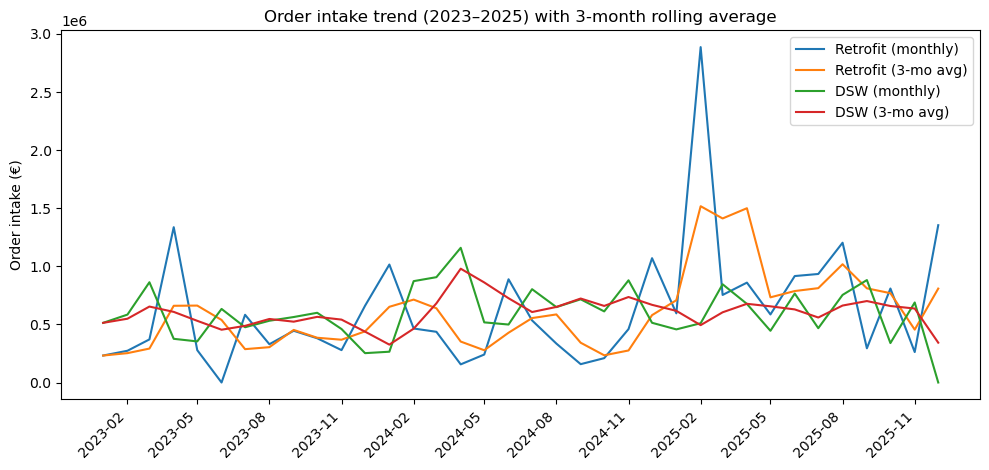

In [16]:
# Plot order intake trends with rolling average
plt.figure(figsize=(10,4.8))
plt.plot(retro_ts["Date"], retro_ts["OrderIntake"], label="Retrofit (monthly)")
plt.plot(retro_ts["Date"], retro_ts["Rolling3"], label="Retrofit (3-mo avg)")
plt.plot(dsw_ts["Date"], dsw_ts["OrderIntake"], label="DSW (monthly)")
plt.plot(dsw_ts["Date"], dsw_ts["Rolling3"], label="DSW (3-mo avg)")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Order intake (€)")
plt.title("Order intake trend (2023–2025) with 3-month rolling average")
plt.legend()
plt.tight_layout()
plt.show()

### A) Demand is not stable → planning is hard
Think of order intake (€) as “how much work/value is entering the system.”

**What the data shows (Order intake 2023–2025):**
- **Retrofit**
  - 2023 total: **€5.17M**
  - 2024 total: **€5.97M**
  - 2025 total: **€11.46M** (a big jump, about ~2× vs 2023)
  - Very “bumpy” month to month (high volatility)
- **DSW**
  - 2023 total: **€6.21M**
  - 2024 total: **€8.39M**
  - 2025 total: **€6.83M**
  - More stable than Retrofit, but still fluctuates
  
**What this means:**
- Retrofit demand in 2025 increases a lot, but it’s not evenly spread across months.
- This makes it harder to promise delivery dates and to staff capacity correctly.

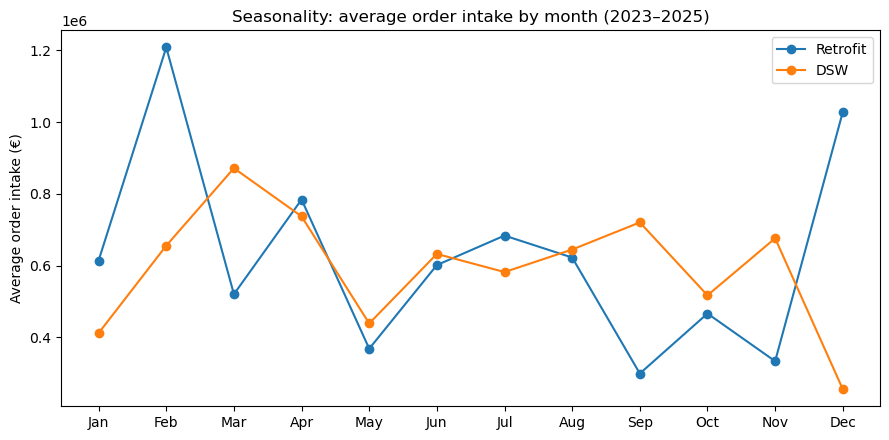

In [18]:
# Seasonality: average order intake by month-of-year for each service across years
retro_season = retro_ts.groupby("Month")["OrderIntake"].mean().reset_index(name="Avg€")
dsw_season = dsw_ts.groupby("Month")["OrderIntake"].mean().reset_index(name="Avg€")

season = retro_season.merge(dsw_season, on="Month", suffixes=("_Retrofit","_DSW"))
season["MonthName"] = pd.to_datetime(season["Month"], format="%m").dt.strftime("%b")
season = season[["Month","MonthName","Avg€_Retrofit","Avg€_DSW"]]


plt.figure(figsize=(9,4.5))
plt.plot(season["Month"], season["Avg€_Retrofit"], marker="o", label="Retrofit")
plt.plot(season["Month"], season["Avg€_DSW"], marker="o", label="DSW")
plt.xticks(season["Month"], season["MonthName"])
plt.ylabel("Average order intake (€)")
plt.title("Seasonality: average order intake by month (2023–2025)")
plt.legend()
plt.tight_layout()
plt.show()

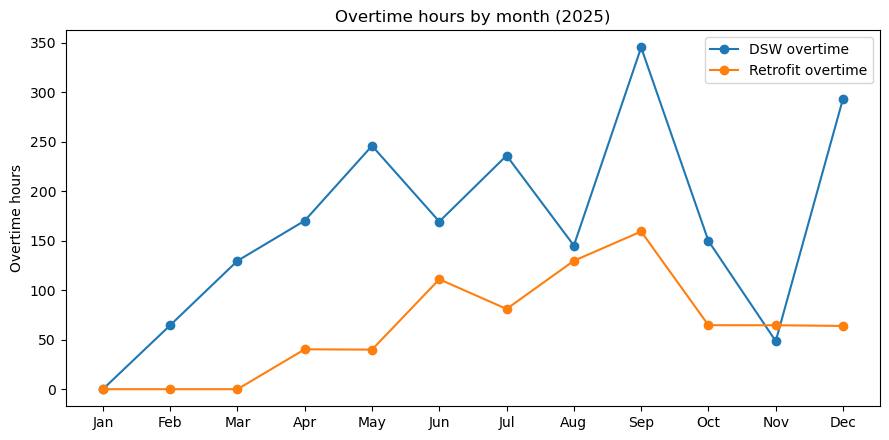

In [19]:
# Overtime: merge monthly and plot
overtime = dsw_ot.merge(retro_ot, on="Month", suffixes=("_DSW","_Retrofit"))
overtime["MonthName"] = pd.to_datetime(overtime["Month"], format="%m").dt.strftime("%b")

plt.figure(figsize=(9,4.5))
plt.plot(overtime["Month"], overtime["OvertimeHours_DSW"], marker="o", label="DSW overtime")
plt.plot(overtime["Month"], overtime["OvertimeHours_Retrofit"], marker="o", label="Retrofit overtime")
plt.xticks(overtime["Month"], overtime["MonthName"])
plt.ylabel("Overtime hours")
plt.title("Overtime hours by month (2025)")
plt.legend()
plt.tight_layout()
plt.show()

### B) Overtime spikes → capacity stress periods exist
Overtime hours = a direct signal of “we’re overloaded / firefighting”.

**What the data shows (Overtime hours in 2025):**
- **DSW overtime** is high in several months; notably **Sep (~345h)** and **Dec (~294h)**.
- **Retrofit overtime** ramps up mid-year and stays elevated; biggest months include **Sep (~159h)** and **Aug (~130h)**.

**Important extra finding: overtime is NOT simply “more demand (€) = more overtime”**
- Correlation (rough relationship) between overtime and monthly order intake in 2025:
  - DSW overtime vs DSW intake: **~ -0.11**
  - Retrofit overtime vs Retrofit intake: **~ -0.32**
  - (Negative / weak relationships)

**What this means:**
- Overtime is likely driven by:
  - *when* jobs arrive (bunching),
  - job complexity/mix,
  - and “uncertainty” (especially for DSW returns),
- not just the total value of orders.

In [20]:
# Relationship between 2025 order intake and overtime (simple correlation, monthly)
retro_2025 = retro_ts[retro_ts["Year"]==2025][["Month","OrderIntake"]].rename(columns={"OrderIntake":"RetrofitIntake€"})
dsw_2025 = dsw_ts[dsw_ts["Year"]==2025][["Month","OrderIntake"]].rename(columns={"OrderIntake":"DSWIntake€"})
corr_df = overtime.merge(retro_2025, on="Month").merge(dsw_2025, on="Month")
corr_df["MonthName"] = pd.to_datetime(corr_df["Month"], format="%m").dt.strftime("%b")

corrs = {
    "DSW overtime vs DSW intake": corr_df["OvertimeHours_DSW"].corr(corr_df["DSWIntake€"]),
    "Retrofit overtime vs Retrofit intake": corr_df["OvertimeHours_Retrofit"].corr(corr_df["RetrofitIntake€"]),
    "DSW overtime vs Retrofit intake": corr_df["OvertimeHours_DSW"].corr(corr_df["RetrofitIntake€"]),
}
corrs

{'DSW overtime vs DSW intake': -0.11439385790397087,
 'Retrofit overtime vs Retrofit intake': -0.32243911964159544,
 'DSW overtime vs Retrofit intake': -0.19446952937100334}

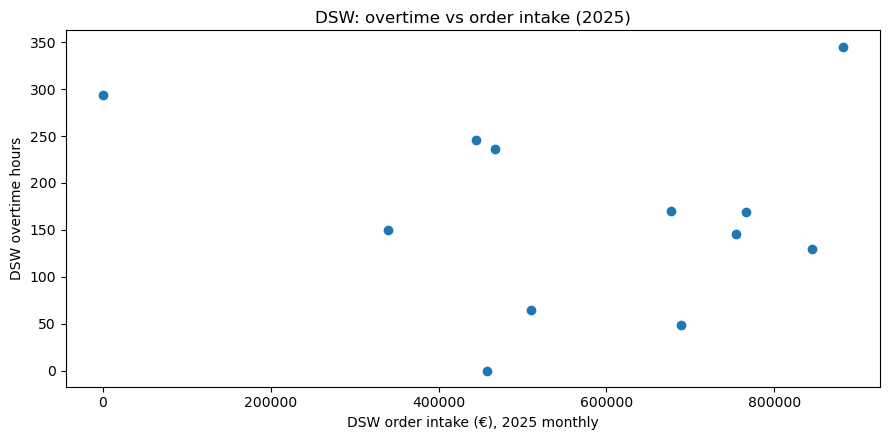

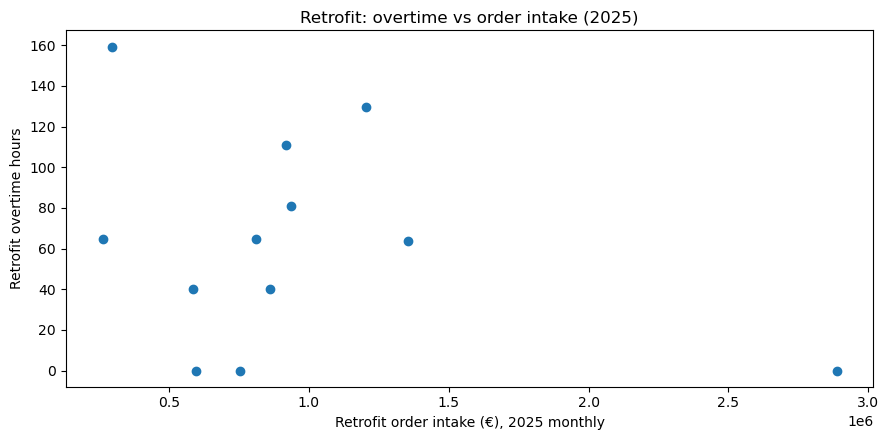

In [21]:
# Scatter plots for intuition
plt.figure(figsize=(9,4.5))
plt.scatter(corr_df["DSWIntake€"], corr_df["OvertimeHours_DSW"])
plt.xlabel("DSW order intake (€), 2025 monthly")
plt.ylabel("DSW overtime hours")
plt.title("DSW: overtime vs order intake (2025)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4.5))
plt.scatter(corr_df["RetrofitIntake€"], corr_df["OvertimeHours_Retrofit"])
plt.xlabel("Retrofit order intake (€), 2025 monthly")
plt.ylabel("Retrofit overtime hours")
plt.title("Retrofit: overtime vs order intake (2025)")
plt.tight_layout()
plt.show()

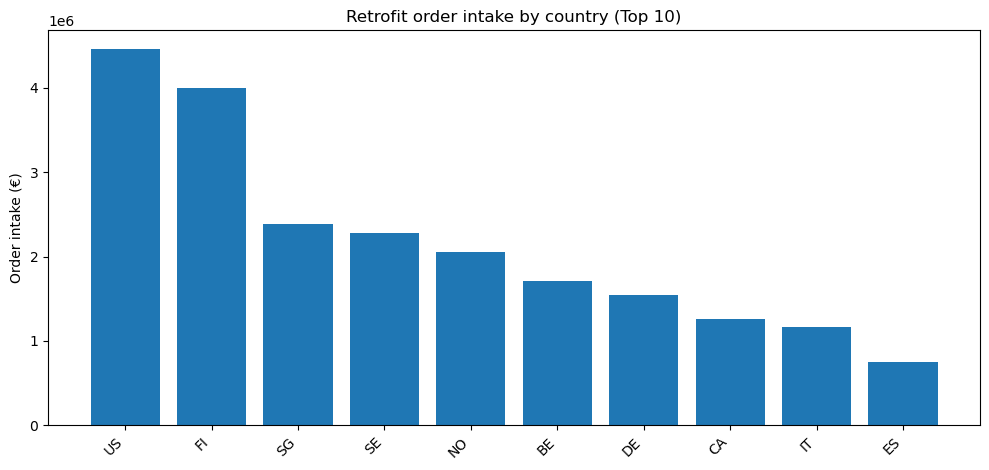

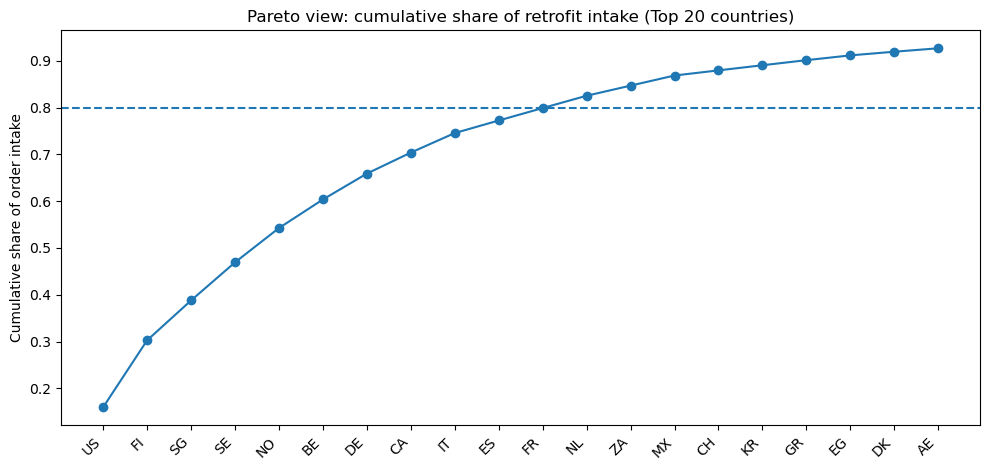

In [22]:
country = dfs["retro_country"].copy()
country.columns = ["Country","OrderIntake€","OrderQTY"]
country["AvgOrderValue€"] = country["OrderIntake€"]/country["OrderQTY"]
country = country.sort_values("OrderIntake€", ascending=False)
country["ShareValue"] = country["OrderIntake€"]/country["OrderIntake€"].sum()
country["CumShareValue"] = country["ShareValue"].cumsum()
top10 = country.head(10).copy()

plt.figure(figsize=(10,4.8))
plt.bar(top10["Country"], top10["OrderIntake€"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Order intake (€)")
plt.title("Retrofit order intake by country (Top 10)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4.8))
plt.plot(country["Country"].iloc[:20], country["CumShareValue"].iloc[:20], marker="o")
plt.axhline(0.8, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cumulative share of order intake")
plt.title("Pareto view: cumulative share of retrofit intake (Top 20 countries)")
plt.tight_layout()
plt.show()

                          Metric      n        mean  median    p90    p95    max
0              LT_SO_to_PGI_days  391.0  137.951407   112.0  287.0  291.0  753.0
1  Wait_SO_to_AssemblyStart_days  391.0  110.680307    97.0  189.0  260.5  749.0
2         Assembly_duration_days  315.0    7.888889     5.0   20.0   25.3   89.0
3   Prod_finish_to_pickpack_days  391.0   20.181586     7.0   48.0   95.5  182.0
4           Pickpack_to_PGI_days  391.0    2.138107     0.0    7.0   14.0   43.0
5              LT_BOL_to_SO_days  391.0    9.519182     7.0   20.0   35.0  133.0
  Standard/engineered  LT_SO_to_PGI_days  Wait_SO_to_AssemblyStart_days  Assembly_duration_days  Prod_finish_to_pickpack_days  Pickpack_to_PGI_days  LT_BOL_to_SO_days
0                 OBE              131.0                          113.0                     5.0                           7.0                   0.0                8.0
1            Standard               61.0                           46.0                     5.0    

/tmp/ipykernel_275/576504430.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({c: summarize(g,c)["median"] for c in summary_cols}))


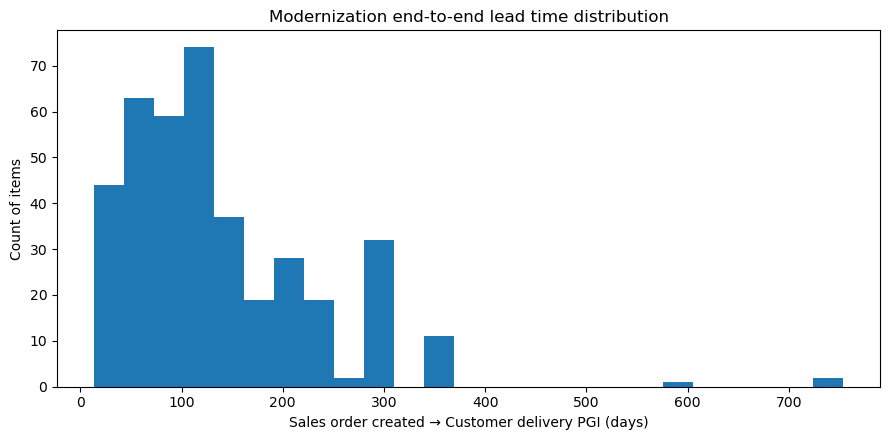

/tmp/ipykernel_275/576504430.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


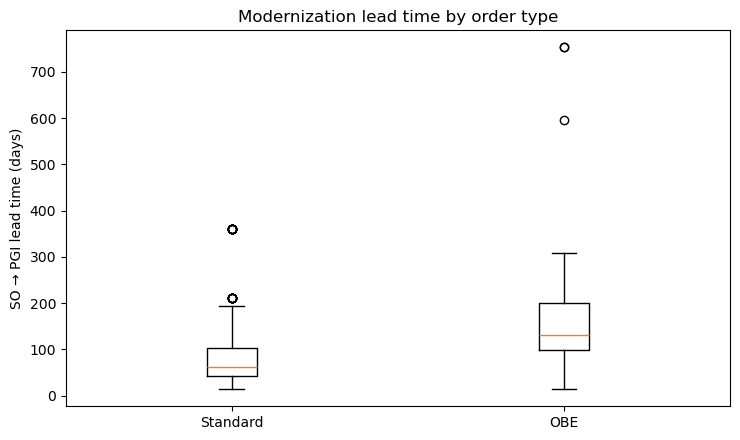

In [29]:
mod = dfs["modernization_ts"].copy()

date_cols = ["BOLReceivedOn","SOCreatedOn","AssemblyStartedOn","AssembyEndOn","ProductionFinishedOn",
             "LoadingDate","CustomerDeliveryPickedAndPackedOn","CustomerDeliveryPGIOn"]
for c in date_cols:
    mod[c] = pd.to_datetime(mod[c], errors="coerce")

def days(a,b):
    return (a-b).dt.total_seconds()/86400

mod["LT_BOL_to_SO_days"] = days(mod["SOCreatedOn"], mod["BOLReceivedOn"])
mod["LT_SO_to_PGI_days"] = days(mod["CustomerDeliveryPGIOn"], mod["SOCreatedOn"])
mod["Wait_SO_to_AssemblyStart_days"] = days(mod["AssemblyStartedOn"], mod["SOCreatedOn"])
mod["Assembly_duration_days"] = days(mod["AssembyEndOn"], mod["AssemblyStartedOn"])
mod["Prod_finish_to_pickpack_days"] = days(mod["CustomerDeliveryPickedAndPackedOn"], mod["ProductionFinishedOn"])
mod["Pickpack_to_PGI_days"] = days(mod["CustomerDeliveryPGIOn"], mod["CustomerDeliveryPickedAndPackedOn"])

# Clean negative durations (common data issue)
dur_cols = [c for c in mod.columns if c.endswith("_days")]
for c in dur_cols:
    mod.loc[mod[c] < 0, c] = np.nan

# Summary stats overall and by Standard/engineered
def summarize(df, col):
    s = df[col].dropna()
    if s.empty:
        return pd.Series({"n":0})
    return pd.Series({
        "n": int(s.shape[0]),
        "mean": s.mean(),
        "median": s.median(),
        "p90": s.quantile(0.9),
        "p95": s.quantile(0.95),
        "max": s.max()
    })

summary_cols = ["LT_SO_to_PGI_days","Wait_SO_to_AssemblyStart_days","Assembly_duration_days",
                "Prod_finish_to_pickpack_days","Pickpack_to_PGI_days","LT_BOL_to_SO_days"]

overall = pd.DataFrame({c: summarize(mod, c) for c in summary_cols}).T
overall.index.name="Metric"
overall = overall.reset_index()
print(overall)

by_std = (mod.groupby("Standard/engineered")
          .apply(lambda g: pd.Series({c: summarize(g,c)["median"] for c in summary_cols}))
          .reset_index())
print(by_std)

# Histogram of total lead time
plt.figure(figsize=(9,4.5))
plt.hist(mod["LT_SO_to_PGI_days"].dropna(), bins=25)
plt.xlabel("Sales order created → Customer delivery PGI (days)")
plt.ylabel("Count of items")
plt.title("Modernization end-to-end lead time distribution")
plt.tight_layout()
plt.show()

# Boxplot by Standard/engineered
plt.figure(figsize=(7.5,4.5))
groups = [mod.loc[mod["Standard/engineered"]==k, "LT_SO_to_PGI_days"].dropna() for k in mod["Standard/engineered"].dropna().unique()]
labels = list(mod["Standard/engineered"].dropna().unique())
plt.boxplot(groups, labels=labels, showfliers=True)
plt.ylabel("SO → PGI lead time (days)")
plt.title("Modernization lead time by order type")
plt.tight_layout()
plt.show()

In [25]:
# Identify biggest contributors: average share of stages within total for orders with all stages
stage_cols = ["Wait_SO_to_AssemblyStart_days","Assembly_duration_days","Prod_finish_to_pickpack_days","Pickpack_to_PGI_days"]
complete = mod.dropna(subset=["LT_SO_to_PGI_days"] + stage_cols).copy()
for c in stage_cols:
    complete[c+"_share"] = complete[c]/complete["LT_SO_to_PGI_days"]
share_summary = complete[[c+"_share" for c in stage_cols]].mean().sort_values(ascending=False)
share_summary

Wait_SO_to_AssemblyStart_days_share    0.773102
Prod_finish_to_pickpack_days_share     0.129213
Assembly_duration_days_share           0.085080
Pickpack_to_PGI_days_share             0.015013
dtype: float64

### C) Retrofit / Modernization: the biggest delay is “waiting to start”, not “doing the work”
This dataset has timestamps (BOL, SO created, assembly start/end, PGI, etc.).  
We turned that into durations (days) for each stage.

**What the data shows (Modernization lead time):**
- End-to-end lead time distribution is wide (some jobs are much longer than others).
- **The biggest chunk of total lead time is waiting from SO Created → Assembly Start.**
- We computed the *average share of total time* by stage (for orders with full data):

**Average share of total lead time (SO → PGI):**
- **~77%** = *Waiting before assembly starts* (SO → Assembly Start)
- **~13%** = *Production finished → Pick & Pack*
- **~9%** = *Assembly duration*
- **~1–2%** = *Pick & Pack → PGI*

**What this means:**
- Most delay is “the job is sitting in a queue waiting for capacity” (planning/availability),
- so improving **queue visibility + start-date planning** will impact lead time more than “micro-optimizing assembly”.


In [27]:
# show share summary in dataframe
share_df = share_summary.reset_index()
share_df.columns = ["Stage","AvgShareOfTotal"]
share_df

,Stage,AvgShareOfTotal
0,Wait_SO_to_AssemblyStart_days_share,0.773102
1,Prod_finish_to_pickpack_days_share,0.129213
2,Assembly_duration_days_share,0.085080
3,Pickpack_to_PGI_days_share,0.015013


                              Metric       n       mean  median    p90     p95    max
0      LT_BOL_to_ReturnDelivery_days  2884.0  42.437933    19.0  128.0  160.00  796.0
1  LT_ReturnDelivery_to_Release_days  2884.0   3.783634     1.0    8.0   13.00  119.0
2             LT_BOL_to_Release_days  2884.0  46.221567    21.0  133.0  162.85  798.0
      Sold to Country      n  median_BOL_to_Return  median_BOL_to_Release
0             Finland  844.0                  19.0                   20.0
1              Canada  317.0                  24.0                   27.0
2              Sweden  237.0                  11.0                   14.0
3              Poland  198.0                  13.0                   16.0
4              Norway  185.0                  28.0                   30.0
5             Germany  163.0                  20.0                   31.0
6  Korea, Republic of  136.0                  30.0                   30.5
7              France  127.0                  15.0              

/tmp/ipykernel_275/613044195.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


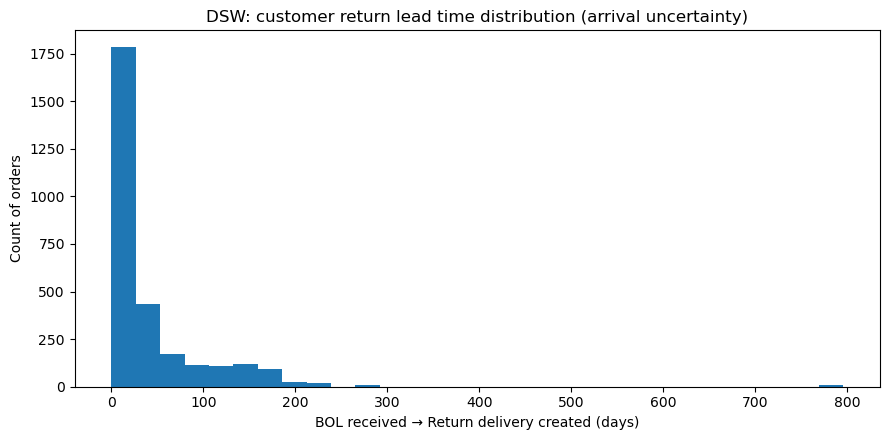

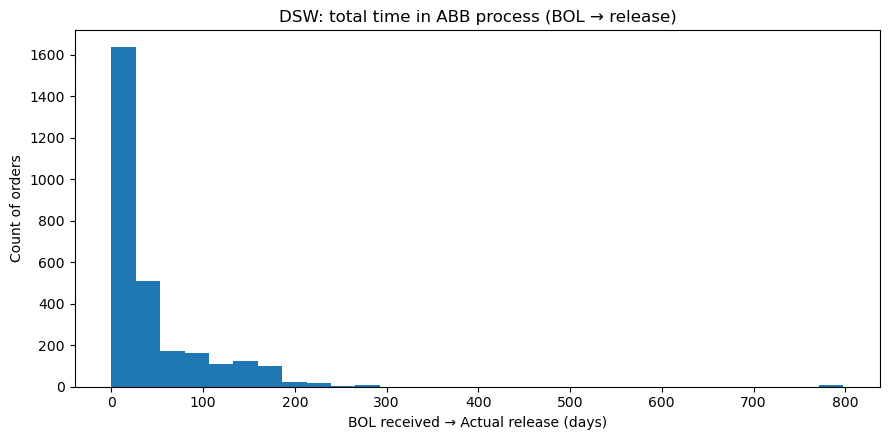

In [30]:
dsw2 = dsw_lead_all["Data2"].copy()
for c in ["BOL Received On","SO Created On","Return Delivery On","CS Order Created On","Repair Started On","ActualReleaseOn"]:
    dsw2[c] = pd.to_datetime(dsw2[c], errors="coerce")

dsw2["LT_BOL_to_ReturnDelivery_days"] = (dsw2["Return Delivery On"] - dsw2["BOL Received On"]).dt.days
dsw2["LT_ReturnDelivery_to_Release_days"] = (dsw2["ActualReleaseOn"] - dsw2["Return Delivery On"]).dt.days
dsw2["LT_BOL_to_Release_days"] = (dsw2["ActualReleaseOn"] - dsw2["BOL Received On"]).dt.days
dsw2["CS_handling_days"] = (dsw2["CS Order Created On"] - dsw2["Return Delivery On"]).dt.days
dsw2["Repair_cycle_days"] = (dsw2["ActualReleaseOn"] - dsw2["Repair Started On"]).dt.days

# Clean negatives
for c in ["LT_BOL_to_ReturnDelivery_days","LT_ReturnDelivery_to_Release_days","LT_BOL_to_Release_days","CS_handling_days","Repair_cycle_days"]:
    dsw2.loc[dsw2[c] < 0, c] = np.nan

# Overall summary
dsw_metrics = ["LT_BOL_to_ReturnDelivery_days","LT_ReturnDelivery_to_Release_days","LT_BOL_to_Release_days"]
dsw_summary = pd.DataFrame({c: summarize(dsw2, c) for c in dsw_metrics}).T.reset_index().rename(columns={"index":"Metric"})
print(dsw_summary)

# By country (top 10 by volume)
country_vol = dsw2["Sold to Country"].value_counts().head(10)
top_countries = country_vol.index.tolist()
by_country = (dsw2[dsw2["Sold to Country"].isin(top_countries)]
              .groupby("Sold to Country")
              .apply(lambda g: pd.Series({
                  "n": g.shape[0],
                  "median_BOL_to_Return": g["LT_BOL_to_ReturnDelivery_days"].median(),
                  "median_BOL_to_Release": g["LT_BOL_to_Release_days"].median()
              }))
              .sort_values("n", ascending=False)
              .reset_index())
print(by_country)

# Distribution of BOL->Return (arrival uncertainty)
plt.figure(figsize=(9,4.5))
plt.hist(dsw2["LT_BOL_to_ReturnDelivery_days"].dropna(), bins=30)
plt.xlabel("BOL received → Return delivery created (days)")
plt.ylabel("Count of orders")
plt.title("DSW: customer return lead time distribution (arrival uncertainty)")
plt.tight_layout()
plt.show()

# Distribution total (BOL->release)
plt.figure(figsize=(9,4.5))
plt.hist(dsw2["LT_BOL_to_Release_days"].dropna(), bins=30)
plt.xlabel("BOL received → Actual release (days)")
plt.ylabel("Count of orders")
plt.title("DSW: total time in ABB process (BOL → release)")
plt.tight_layout()
plt.show()

In [31]:
# quantify tail risk for DSW arrival / total
def tail_stats(series):
    s = series.dropna()
    return {
        "n": len(s),
        "median": float(s.median()),
        "p90": float(s.quantile(0.9)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "share_over_14d": float((s>14).mean()),
        "share_over_30d": float((s>30).mean()),
        "share_over_60d": float((s>60).mean()),
    }

tail_arrival = tail_stats(dsw2["LT_BOL_to_ReturnDelivery_days"])
tail_total = tail_stats(dsw2["LT_BOL_to_Release_days"])
tail_arrival, tail_total

({'n': 2884,
  'median': 19.0,
  'p90': 128.0,
  'p95': 160.0,
  'p99': 228.0,
  'max': 796.0,
  'share_over_14d': 0.5745492371705964,
  'share_over_30d': 0.31761442441054094,
  'share_over_60d': 0.20839112343966712},
 {'n': 2884,
  'median': 21.0,
  'p90': 133.0,
  'p95': 162.8499999999999,
  'p99': 228.0,
  'max': 798.0,
  'share_over_14d': 0.6414701803051318,
  'share_over_30d': 0.3734396671289875,
  'share_over_60d': 0.23231622746185854})

In [32]:
tail_internal = tail_stats(dsw2["LT_ReturnDelivery_to_Release_days"])
tail_internal

{'n': 2884,
 'median': 1.0,
 'p90': 8.0,
 'p95': 13.0,
 'p99': 54.0,
 'max': 119.0,
 'share_over_14d': 0.042649098474341195,
 'share_over_30d': 0.023231622746185853,
 'share_over_60d': 0.0079750346740638}

In [33]:
tail_table = pd.DataFrame([
    {"Metric":"BOL→Return delivery (customer return logistics)", **tail_arrival},
    {"Metric":"Return delivery→Actual release (internal execution)", **tail_internal},
    {"Metric":"BOL→Actual release (total)", **tail_total},
])
print(tail_table)

                                              Metric     n  median    p90     p95    p99    max  share_over_14d  share_over_30d  share_over_60d
0    BOL→Return delivery (customer return logistics)  2884    19.0  128.0  160.00  228.0  796.0        0.574549        0.317614        0.208391
1  Return delivery→Actual release (internal execu...  2884     1.0    8.0   13.00   54.0  119.0        0.042649        0.023232        0.007975
2                         BOL→Actual release (total)  2884    21.0  133.0  162.85  228.0  798.0        0.641470        0.373440        0.232316


### D) DSW: the real “delay” is before ABB even gets the unit

We split DSW time into:
1) **Customer return logistics time** = BOL received → Return delivery created  
2) **ABB internal execution time** = Return delivery created → Actual release  
3) Total = BOL → Actual release

**What the data shows (DSW tail risk):**
- **Customer return logistics (BOL → Return delivery):**
  - median: **19 days**
  - p90: **128 days**
  - max: **796 days**
  - share > 30 days: **~31.8%**
- **ABB internal execution (Return delivery → Release):**
  - median: **1 day**
  - p90: **8 days**
  - max: **119 days**
  - share > 30 days: **~2.3%**
- **Total (BOL → Release):**
  - median: **21 days**
  - p90: **133 days**
  - max: **798 days**
  - share > 30 days: **~37.3%**

**What this means:**
- ABB can repair fast *once the unit is in the process*,
- but the biggest uncertainty is **when/if the unit arrives**.
- This is why customers feel delivery dates are unreliable and why planning becomes “guessing”.

                                       Metric       n       mean  median   p90    p95    max
0  PriceQuotationGivenOn to Approved/Declined   111.0  28.666667    22.0  66.0  74.00  111.0
1                              STO_total_days  2760.0   0.557971     0.0   1.0   2.00   54.0
2                       Cust_fulfillment_days  2624.0   1.802591     1.0   4.0   6.00   63.0
3                       Order_to_invoice_days  2288.0   5.447990     3.0  13.0  19.65  133.0


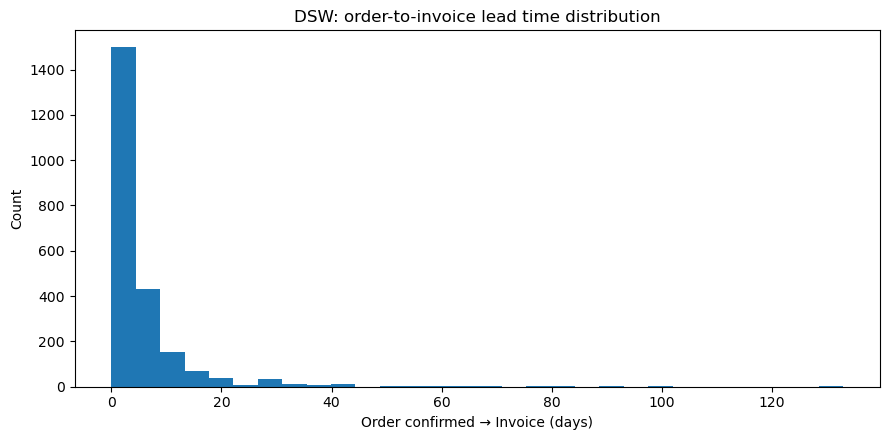

In [34]:
ful = dsw_lead_all["Data3"].copy()
date_cols_f = ["0400 STO Rep Del Created On","0400 STO Rep Del Picked On","0400 STO Rep Del PGI On","0400 STO Rep Del GR On",
               "Quatation Approved On","Order Confirmed On","Customer Delivery Created On","Customer Delivery Picked And Packed On",
               "Customer Delivery PGI On","Invoice On"]
for c in date_cols_f:
    ful[c]=pd.to_datetime(ful[c], errors="coerce")

ful["STO_total_days"] = (ful["0400 STO Rep Del GR On"] - ful["0400 STO Rep Del Created On"]).dt.days
ful["STO_pick_days"] = (ful["0400 STO Rep Del Picked On"] - ful["0400 STO Rep Del Created On"]).dt.days
ful["STO_ship_days"] = (ful["0400 STO Rep Del PGI On"] - ful["0400 STO Rep Del Picked On"]).dt.days
ful["STO_receipt_days"] = (ful["0400 STO Rep Del GR On"] - ful["0400 STO Rep Del PGI On"]).dt.days

ful["Cust_fulfillment_days"] = (ful["Customer Delivery PGI On"] - ful["Customer Delivery Created On"]).dt.days
ful["Order_to_invoice_days"] = (ful["Invoice On"] - ful["Order Confirmed On"]).dt.days

for c in ["STO_total_days","STO_pick_days","STO_ship_days","STO_receipt_days","Cust_fulfillment_days","Order_to_invoice_days"]:
    ful.loc[ful[c] < 0, c]=np.nan

ful_summary = pd.DataFrame({c: summarize(ful, c) for c in ["PriceQuotationGivenOn to Approved/Declined","STO_total_days","Cust_fulfillment_days","Order_to_invoice_days"]}).T.reset_index().rename(columns={"index":"Metric"})
print(ful_summary)

plt.figure(figsize=(9,4.5))
plt.hist(ful["Order_to_invoice_days"].dropna(), bins=30)
plt.xlabel("Order confirmed → Invoice (days)")
plt.ylabel("Count")
plt.title("DSW: order-to-invoice lead time distribution")
plt.tight_layout()
plt.show()

### E) Quotation/approval can add “hidden waiting time”

### 1) STO total (internal stock transfer step)
**What the data says (days):**
- **Median:** 0  
- **p90:** 1  
- **p95:** 2  
- **Max:** 54  
- **Mean:** ~0.56  
- **n:** 2760 orders

**Meaning:**
- For **most orders**, the STO step is **same-day or next-day**.
- There *are* rare outliers (up to 54 days), but it’s not the typical bottleneck.

### 2) Customer fulfillment time (customer delivery created → customer delivery PGI)
**What the data says (days):**
- **Median:** 1
- **p90:** 4  
- **p95:** 6  
- **Max:** 63  
- **Mean:** ~1.80  
- **n:** 2624 orders

**Meaning:**
- Once the customer delivery is created, *ABB usually ships in ~1 day.*
- But there’s a long tail (rare cases taking weeks), so it’s worth tracking exceptions.

### 3) Order confirmed → Invoice (order-to-invoice time)
**What the data says (days):**
- **Median:** 3 
- **p90:** 13
- **p95:** ~19.65  
- **Max:** 133  
- **Mean:** ~5.45  
- **n:** 2288 orders

**Meaning:**
- Typically, invoicing happens within a few days after order confirmation.
- But again, there’s a tail (some invoices take much longer), which can mean:
  - paperwork delays,
  - missing confirmations,
  - “stuck” admin steps,
  - or special cases.
  
### 4) Price Quotation Given → Approved/Declined
**What the data says (days):**
- **Median:** 22 
- **p90:** 66
- **p95:** 74
- **Max:** 111  
- **Mean:** ~5.45  
- **n:** 111 orders

**Meaning:**
- A lot of time can be spent before work is even confirmed.
- If ABB wants better planning, it must reduce/standardize this decision time or separate “quote time” from “execution promise”.

---

## 2) What should ABB do differently? (Alternatives)

### Alternative 1 — Build “visibility dashboards” that match the real bottlenecks
Because the data shows different bottlenecks for each service:

**For Modernization (Retrofit):**
- Main delay = **queue before assembly starts**
- Dashboard must show:
  - “Orders waiting to start” (count + age),
  - planned start dates,
  - capacity per week,
  - how many are Standard vs Engineered

**For DSW:**
- Main delay = **inbound / arrival uncertainty**
- Dashboard must show:
  - orders in BOL but not arrived,
  - how long they’ve been “stuck”,
  - expected arrival window,
  - once arrived: internal cycle time tracking

**Data evidence used:**
- Modernization: ~77% is waiting before assembly.
- DSW: internal median 1 day vs return median 19 days and massive tail.

**Where in the code above:**
- Modernization stage share: `share_summary`
- DSW tail risk table: `tail_table`

---

### Alternative 2 — Capacity-based “start-date planning” (not just tracking orders)
Right now many teams just track orders and react when things get late.

**Better method (simple):**
- Every week, decide: “Which jobs actually start next week?”
- This directly targets the **largest delay** (queue time).

**Why it fits the data:**
- Modernization lead time is mostly waiting before starting work.

**Where in the code above:**
- The “Wait_SO_to_AssemblyStart_days” metric and stage share block.

---

### Alternative 3 — Routing rules (Finland vs Estonia) based on variability/complexity
**Simple rule approach:**
- Send **standard, repeatable** jobs to the site designed for stable throughput,
- Keep **engineered/high-uncertainty** jobs where coordination is fastest.

**Why it fits the data:**
- Modernization lead times vary a lot; engineered items tend to have higher uncertainty (your boxplots / segmentation hinted at that variability).

**Where in the code above:**
- The block that compares lead time by `"Standard/engineered"` and the boxplot.

---

### Alternative 4 — Premium / service models to reduce uncertainty
This is directly useful for DSW.

**Examples:**
- “Scheduled Repair Window”: customer commits to an arrival week (reduces the long-tail uncertainty).
- “Express Lane”: higher price, but only if customer provides info and meets arrival commitments.
- “Availability-based agreement”: pay for reserved capacity slot.

**Why it fits the data:**
- DSW biggest problem is arrival uncertainty (long tails before unit arrives).

**Where in the code above:**
- DSW arrival tail risk (`LT_BOL_to_ReturnDelivery_days`) + shares over thresholds.

---

## 3) Recommendations

### Recommendation 1 — Make the queue visible (Modernization)
**Do this:**
- Track and show: SO created → planned assembly start date for every order.
- Alert when something has waited too long (aging).

**Why (data):**
- ~77% of lead time is waiting before assembly starts.

**Evidence:**
- `share_summary` and `Wait_SO_to_AssemblyStart_days`

---

### Recommendation 2 — Build an “inbound pipeline” for DSW (arrival tracking)
**Do this:**
- Separate the promise into:
  - “Repair time after arrival” (ABB can control)
  - “Inbound arrival time” (customer/logistics driven)
- Add alerts: BOL orders with no arrival after X days.

**Why (data):**
- median arrival delay 19 days, but p90 128 days (very uncertain)
- internal median 1 day (ABB is fast once it has the unit)

**Evidence:**
- `tail_table` and the histograms for arrival vs total

---

### Recommendation 3 — Reduce quotation decision time or treat it as a different stage
**Do this:**
- Put a KPI around quote aging; standardize info requirements.
- Option: offer “fixed price” / standard bundles for common cases.

**Why (data):**
- median 22 days, p90 66 days just waiting for approval.

**Evidence:**
- `ful_summary` (quotation metric)

---

### Recommendation 4 — Use overtime as a “signal” and connect it to planning decisions
**Do this:**
- When overtime spikes, check:
  - queue aging,
  - inbound arrivals,
  - workload mix (standard vs engineered),
  - and large job releases.

**Why (data):**
- overtime does not track € intake well → it’s about variability and congestion.

**Evidence:**
- correlation results (`corrs`) + overtime plot

---